In [1]:
import numpy as np
import torch.utils.data as data
import torchvision.transforms as transforms
import os
import utils

BATCH_SIZE = 256

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
dataset_name = "pathmnist"
num_classes = 9

data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])
from medmnist.dataset import PathMNIST

# load the data

test_dataset = PathMNIST(split='val', size=224, root="/home/bobsun/cambrige/MedMinist/data", transform=data_transform,
                         download=True)

# encapsulate data into dataloader form
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2 * BATCH_SIZE, shuffle=False, num_workers=8)

Using downloaded and verified file: /home/bobsun/cambrige/MedMinist/data/pathmnist_224.npz


In [1]:
dataset_name = "dermamnist"
num_classes = 7

import torch.utils.data as data
import torchvision.transforms as transforms

data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

from medmnist.dataset import DermaMNIST

test_dataset = DermaMNIST(split='test', size=224, root="/home/bobsun/cambrige/MedMinist/data", transform=data_transform,
                          download=True)

test_loader = data.DataLoader(dataset=test_dataset, batch_size=2 * BATCH_SIZE, shuffle=False)



Using downloaded and verified file: /home/bobsun/cambrige/MedMinist/data/dermamnist_224.npz


In [1]:
dataset_name = "pneumoniamnist"
num_classes = 2

import torch.utils.data as data
import torchvision.transforms as transforms

data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize(mean=[.5], std=[.5])
])

from medmnist.dataset import PneumoniaMNIST

test_dataset = PneumoniaMNIST(split='test', size=224, root="/home/bobsun/cambrige/MedMinist/data",
                              transform=data_transform,
                              download=True)

test_loader = data.DataLoader(dataset=test_dataset, batch_size=2 * BATCH_SIZE, shuffle=False)



Using downloaded and verified file: /home/bobsun/cambrige/MedMinist/data/pneumoniamnist_224.npz


In [7]:
dataset_name = "tissuemnist"
num_classes = 8

import torch.utils.data as data
import torchvision.transforms as transforms

data_transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize(mean=[.5], std=[.5])
])

from medmnist.dataset import TissueMNIST

test_dataset = TissueMNIST(split='test', size=224, root="/home/bobsun/cambrige/MedMinist/data",
                           transform=data_transform,
                           download=True)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2 * BATCH_SIZE, shuffle=False)

Using downloaded and verified file: /home/bobsun/cambrige/MedMinist/data/tissuemnist_224.npz


In [1]:
dataset_name = "bloodmnist"
num_classes = 8
import torch.utils.data as data
import torchvision.transforms as transforms

BATCH_SIZE = 128
# preprocessing
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

from medmnist.dataset import BloodMNIST

# load the data
test_dataset = BloodMNIST(split='val', size=224, root="/home/bobsun/cambrige/MedMinist/data", transform=data_transform,
                          download=True)

test_loader = data.DataLoader(dataset=test_dataset, batch_size=2 * BATCH_SIZE, shuffle=False)



Using downloaded and verified file: /home/bobsun/cambrige/MedMinist/data/bloodmnist_224.npz


In [1]:
dataset_name = "organamnist"
num_classes = 11
import torch.utils.data as data
import torchvision.transforms as transforms

BATCH_SIZE = 128
# preprocessing
data_transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize(mean=[.5], std=[.5])
])
data_transform_3 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize(mean=[.5], std=[.5])
])

from medmnist.dataset import OrganAMNIST

# load the data
test_dataset = OrganAMNIST(split='val', size=224, root="/home/bobsun/cambrige/MedMinist/data", transform=data_transform,
                           download=True)

test_loader = data.DataLoader(dataset=test_dataset, batch_size=2 * BATCH_SIZE, shuffle=False)
# test_loader_3 = data.DataLoader(dataset=test_dataset_3, batch_size=2 * BATCH_SIZE, shuffle=False)



Using downloaded and verified file: /home/bobsun/cambrige/MedMinist/data/organamnist_224.npz


In [3]:
def test(model, test_loader):
    model.eval()
    test_total = 0
    test_correct = 0
    # Disable gradient calculation for faster inference
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            targets = targets.squeeze().long()
            # Forward pass
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            # Update correct and total counts
            test_total += targets.size(0)
            test_correct += (predicted == targets).sum().item()

    # Calculate accuracy
    test_accuracy = 100 * test_correct / test_total
    print(f'Test Accuracy: {test_accuracy:.2f}%')
    return test_accuracy

def apply_ablation(model, ablation_count):
    """
    动态设置模型的 DEB 模块的 ablation 状态。
    :param model: DEN_V3 模型实例
    :param ablation_count: 要禁用合作模式的层数
    """
    count = 0
    for layer in [model.layer1, model.layer2, model.layer3, model.layer4]:
        for block in layer:
            if count < ablation_count:
                block.deep_explain.ablate = True  # 启用非合作模式
                count += 1
            else:
                block.deep_explain.ablate = False  # 保持合作模式

In [38]:
import torch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# 加载预训练的 state_dict
#pneumoniamnist_DEN_V5_94.39.pth one_class
#pneumoniamnist_DEN_V5_90.06.pth 2-class
# pneumoniamnist_DEN_V5_91.67.pth 2-class
# Tissue_DEN_V5_66.72.pth
# Derma_DEN_V6_74.61.pth 每层单独训练
# path_DEN_V6_93.27.pth 每层单独训练
# Pneumonia_DEN_V6_90.54.pth
# Blood_DEN_V6_96.23.pth
# Organ_DEN_V6_97.06.pth
# path_DEN_V6_94.33.pth
# path_DEN_V6_93.50.pth
#organ_DEN_V6_88.27.pth
# organ_DEN.pth
# tissue_DEN.pth
# blood_DEN.pth

# ablation:
# path_den_ablation.pth
den_finetune = None
del (den_finetune)
den_finetune = torch.load('path_den_ablation.pth', map_location=device)
# den_finetune = torch.load('path_DEN_V6_94.33.pth', map_location=device)
apply_ablation(den_finetune,8)

# 将模型移动到设备
den_finetune = den_finetune.to(device)
test(den_finetune, test_loader)
# print(den_finetune)

Test Accuracy: 92.88%


92.8828468612555

In [5]:
#path_resnet.pth
# organ_resnet.pth
# tissue_resnet.pth
# blood_resnet.pth
import torch
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
resnet = torch.load('path_resnet.pth', map_location='cpu').to(device)
# test(resnet, test_loader)

In [6]:
from medmnist.info import INFO

INFO[dataset_name]["label"]
# INFO['pathmnist']["label"]
#肺炎 25 26
#tissue 34

# path: 14 19 24 26 29 30 33 41 43!! 48 49!! 54 57 62 76
# path2: 99! 101 105 115!

# organ 23 33 34 38 59 64 69! 71! 76
# inital layer sensitive : 39 76

#derma_v6 0 5 6 14!! 15!! 18!!


In [12]:
# idx += 1 
idx = 14
# blood :4 `5 9 11 12 13 18 22 23! 25 26 32! 33! 39 41! 44! 46 48! 53 63! 67
#non-negativity example: path 24
print(idx)
add_text = True
concatImg(den_finetune, test_loader, idx, non_negative=1, negative=-1, sharpness=1 / num_classes + 0.1,sharpness_n=0 / num_classes + 0.1, dataset_name=dataset_name, activation="activation_all",
          add_text=True,alpha=0.8)
#7 11 18! 23! 40  45! 48! 50! 51! 57! 58! 65! 67! 71! 72!! 73 75 83!! 88!! 90!! 101 102 103!!

14


NameError: name 'den_finetune' is not defined

79
True Class: colorectal adenocarcinoma epithelium


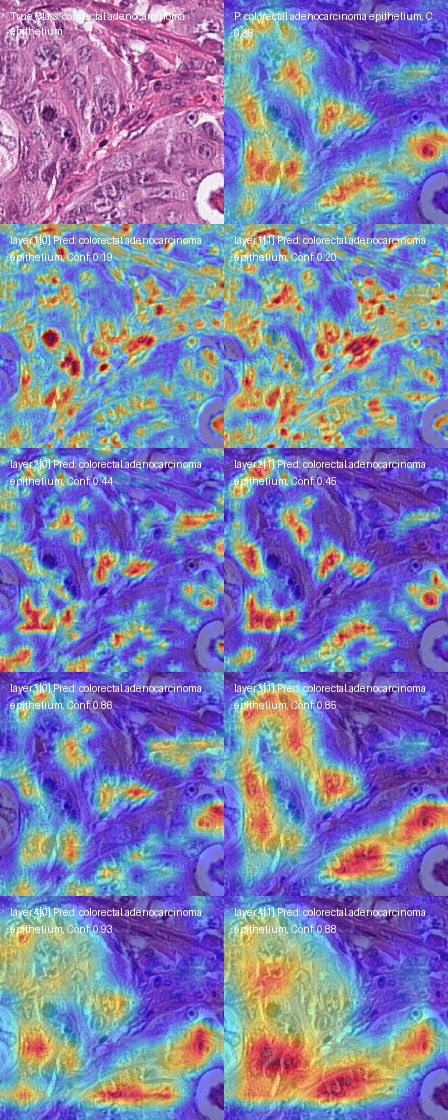

In [107]:
idx +=1
# blood :4 `5 9 11 12 13 18 22 23! 25 26 32! 33! 39 41! 44! 46 48! 53 63! 67
#non-negativity example: path 24
print(idx)
add_text = True
concatImg_ab(den_finetune, test_loader, idx, non_negative=1, negative=-1, sharpness=1 / num_classes + 0.1,sharpness_n=1 / num_classes + 0.1, dataset_name=dataset_name, activation="activation",
          add_text=True,alpha=1)
#7 11 18! 23! 40  45! 48! 50! 51! 57! 58! 65! 67! 71! 72!! 73 75 83!! 88!! 90!! 101 102 103!!

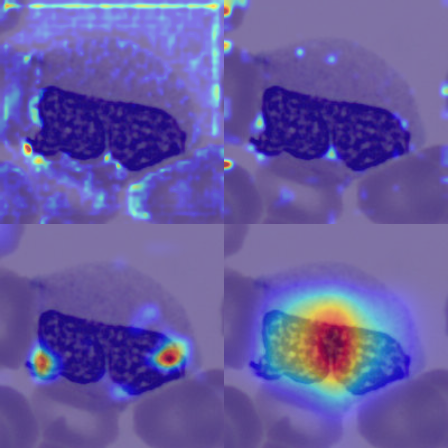

In [151]:
list_ = []
for i in range(1, 5):
    result,_ = generate_grad_cam_image(resnet, test_loader, idx,target_layer=f"layer{i}")
    list_.append(result)
concat_images(list_)

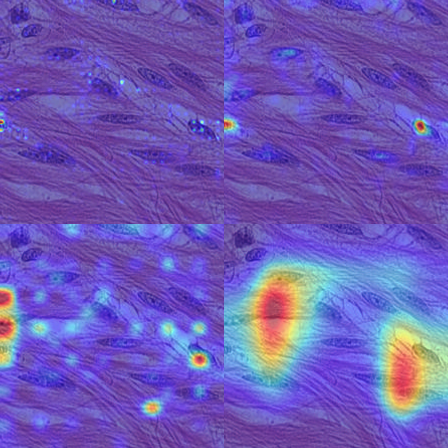

In [13]:
# path: 14 19 24 26 29 30 33 41 43!! 48 49!! 54 57 61 62 71 76
# path2: 99! 101 105 115!
list_ = []
for i in range(1, 5):
    result,_ = generate_layer_cam_image(resnet, test_loader, idx,target_layer=f"layer{i}")
    list_.append(result)
concat_images(list_)

PartitionExplainer explainer: 2it [00:31, 31.51s/it]               


True Class: immature granulocytes(myelocytes, metamyelocytes and promyelocytes)


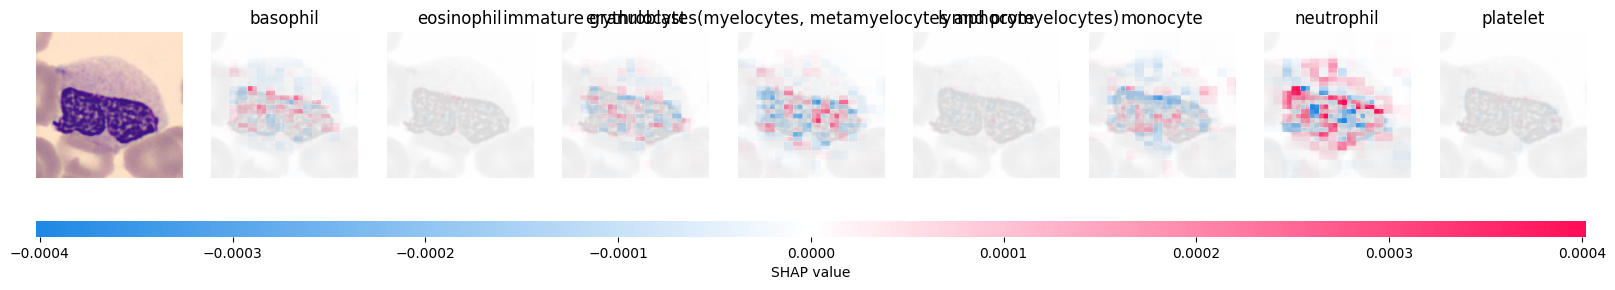

In [153]:
shap_values, class_name = generate_shap_explanation(resnet, test_loader, idx, max_evals=50000, batch_size=256,class_name=dataset_name,masker_type="blur(8,8)")

In [137]:
count = 71

71


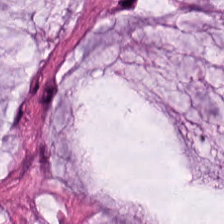

In [138]:
import numpy as np
from PIL import Image
idx = count
print(count)
count += 1

image_tensor = test_dataset[idx][0].permute(1, 2, 0)  # 转换为 (H, W, C)
image_tensor = image_tensor *0.5 + 0.5
image_array = (image_tensor.numpy() * 255).astype(np.uint8)  # 转换为 uint8

img = Image.fromarray(image_array)
img

In [10]:
from torchcam.utils import overlay_mask
from PIL import Image, ImageDraw, ImageFont
import cv2
import numpy as np
import torch
import torch.nn.functional as F
from medmnist import INFO

from PIL import Image, ImageDraw, ImageFont


def add_text_to_image(image, text, position=(10, 10), font_size=40, max_width=None, line_spacing=5, add_text=True):
    """
    在图像上添加支持自动换行的文本。

    参数:
    - image: PIL 图像对象
    - text: 要添加的文本
    - position: 文本在图像上的起始位置
    - font_size: 字体大小
    - max_width: 文本行的最大宽度，如果不指定，则使用图像宽度
    - line_spacing: 行间距

    返回:
    - 带有文本的图像
    """

    if not add_text:
        return image
    draw = ImageDraw.Draw(image)
    try:
        # 尝试加载系统默认字体
        font = ImageFont.truetype("arial", font_size)
    except IOError:
        # 使用默认字体
        font = ImageFont.load_default()

    # 如果没有指定最大宽度，则使用图像宽度
    if max_width is None:
        max_width = image.width - position[0] * 2  # 留出一定边距

    # 拆分文本，逐行添加
    lines = []
    words = text.split()
    current_line = ""
    for word in words:
        # 判断当前行加入下一个词后是否超过最大宽度
        test_line = f"{current_line} {word}".strip()
        left, top, right, bottom = font.getbbox(test_line)
        line_width = right - left
        if line_width <= max_width:
            current_line = test_line
        else:
            # 当前行宽度超限，将当前行加入到行列表并重置
            lines.append(current_line)
            current_line = word

    # 添加最后一行
    if current_line:
        lines.append(current_line)

    # 绘制每一行文本
    x, y = position
    for line in lines:
        draw.text((x, y), line, fill="white", font=font)
        _, _, _, line_height = font.getbbox(line)  # 获取当前行的高度
        y += line_height + line_spacing  # 增加行间距

    return image


def get_weight_with_sharpness(full_weight, y, sharpness, sharpness_n):
    # 确保 full_weight 是 PyTorch 张量
    full_weight_pt = full_weight
    weight_pt = full_weight_pt[y]

    # 转换为 NumPy 数组
    full_weight_np = full_weight_pt
    weight_np = weight_pt

    # 处理负向权重
    full_weight_n = -full_weight_np.copy()
    weight_n = -weight_np.copy()

    # 正向权重处理
    full_weight_np[full_weight_np < 0] = 0
    norm = np.sum(full_weight_np, axis=0)
    weight_np[weight_np < 0] = 0
    alpha = weight_np / (norm + 1e-8)
    weight_np[alpha < sharpness] = 0

    # 负向权重处理
    full_weight_n[full_weight_n < 0] = 0
    norm_n = np.sum(full_weight_n, axis=0)
    weight_n[weight_n < 0] = 0
    alpha_n = weight_n / (norm_n + 1e-8)
    weight_n[alpha_n < sharpness_n] = 0

    # 最终权重
    final_weight = weight_np - weight_n

    return final_weight


def generate_cam_with_overlay(fc_weights, feature_map, class_idx, input_image, non_negative=1.0, negative=0,
                              sharpness=0, sharpness_n=0):
    # print("class_idx:",class_idx)
    weights = fc_weights[class_idx].cpu().detach().numpy()
    if (sharpness > 0 or sharpness_n > 0):
        weights = get_weight_with_sharpness(fc_weights.cpu().detach().numpy(), class_idx, sharpness, sharpness_n)
    B, C, H, W = feature_map.shape
    feature_map = feature_map.cpu().detach().numpy()

    # 计算正向 CAM
    weights_positive = np.clip(weights, a_min=0, a_max=None)
    weights_negative = np.clip(-weights, a_min=0, a_max=None)
    weights_final = non_negative * weights_positive + negative * weights_negative
    cam_positive = np.sum(weights_final[:, None, None] * feature_map[0], axis=0)
    cam_return = cam_positive.copy()

    # 归一化 CAM
    min_val = np.percentile(cam_positive, 1)
    max_val = np.percentile(cam_positive, 99)
    cam_positive = (cam_positive - min_val) / (max_val - min_val)
    cam_positive[cam_positive < 0.1] = 0
    cam_positive[cam_positive > 1.0] = 1.0
    cam_positive_resized = cv2.resize(cam_positive, (input_image.shape[1], input_image.shape[0]))
    cam_return = cv2.resize(cam_return, (input_image.shape[1], input_image.shape[0]))

    # 将激活图转换为 PIL Image 格式
    activation_map = Image.fromarray(cam_positive_resized, mode='F')

    # 使用 overlay_mask 叠加
    overlay_image = overlay_mask(Image.fromarray(input_image), activation_map, alpha=0.5)

    return overlay_image, cam_return


def draw(img_list, input_image=None, cam_list=None, class_names=[], label=0, predicted_class="", confidence=0.0):
    # 累加所有 CAM，并进行归一化处理

    if input_image is not None:
        all_cam = np.sum(cam_list, axis=0)
        all_cam = (all_cam - all_cam.min()) / (all_cam.max() - all_cam.min())

        # 将叠加的 CAM 转换为 PIL Image 格式
        all_cam_img = Image.fromarray(all_cam, mode='F')
        overlay_all_cam = overlay_mask(Image.fromarray(input_image), all_cam_img, alpha=0.5)

        # 在原图上添加实际类别
        original_image_with_text = add_text_to_image(Image.fromarray(input_image), f"True Class: {class_names[label]}")
        # 在全叠加的 CAM 图上添加预测类别和置信度
        overlay_all_cam_with_text = add_text_to_image(overlay_all_cam, f"P: {predicted_class}, C: {confidence:.2f}")

        # 创建包含原图和叠加激活图的图像
        img_list.insert(0, [original_image_with_text, overlay_all_cam_with_text])
    layer_images = []

    # 拼接各层的激活图
    for i, layer in enumerate(img_list):
        widths, heights = zip(*(img.size for img in layer))
        total_width = sum(widths)
        max_height = max(heights)

        # 创建一个空白图像来存放水平拼接结果
        layer_image = Image.new('RGB', (total_width, max_height))

        # 逐个粘贴图像并添加对应层级的预测信息
        x_offset = 0
        for j, img in enumerate(layer):
            # 如果是每层的 CAM 图，添加层的预测文本
            if i > 0:  # 跳过原图和 all_cam 图
                text = f"layer{i}[{j}] Pred: {class_names[j]}, Conf: {confidence:.2f}"
                # img = add_text_to_image(img, text)
            layer_image.paste(img, (x_offset, 0))
            x_offset += img.width

        layer_images.append(layer_image)

    # 垂直拼接所有层
    widths, heights = zip(*(img.size for img in layer_images))
    max_width = max(widths)
    total_height = sum(heights)

    final_image = Image.new('RGB', (max_width, total_height))
    y_offset = 0
    for layer_image in layer_images:
        final_image.paste(layer_image, (0, y_offset))
        y_offset += layer_image.height

    return final_image



def concatImg_ab(model, test_loader, idx, non_negative=1, negative=0, class_=-1, sharpness=0, sharpness_n=0,
              dataset_name="dermamnist", activation="activation", add_text=True, alpha=1):
    images, labels = next(iter(test_loader))
    img_tensor = images[idx].to(device).unsqueeze(0)
    label = labels[idx].item()
    class_names = [label for _, label in INFO[dataset_name]["label"].items()]
    print(f"True Class: {class_names[label]}")

    # label = 0
    # 获取模型输出
    output = model(img_tensor)
    # print(f"Predicted Class: {predicted_class}, Confidence: {confidence:.2f}")
    original_image = img_tensor.cpu().squeeze().numpy()
    if original_image.ndim == 2:  # 单通道 (H, W)
        display_image = (original_image * 0.5 + 0.5) * 255  # 转换到 [0, 255]
        input_image = np.stack([display_image] * 3, axis=-1)  # 转为三通道
    elif original_image.ndim == 3:  # 多通道 (C, H, W)
        input_image = (original_image.transpose(1, 2, 0) * 0.5 + 0.5) * 255

    input_image = input_image.astype('uint8')

    img_list = []
    cam_list = []
    for i in range(1, 5):
        layer_list = []
        for j in range(2):
            pred_fc = getattr(getattr(getattr(model, f'layer{i}')[j], 'deep_explain'), 'pred_fc').weight
            W = getattr(getattr(getattr(model, f'layer{i}')[j], 'deep_explain'), 'W').weight
            weight = pred_fc # @ W
            feature_map = getattr(getattr(getattr(model, f'layer{i}')[j], 'deep_explain'), activation)
            logit = getattr(getattr(getattr(model, f'layer{i}')[j], 'deep_explain'), 'deep_pred')
            probabilities = F.softmax(logit, dim=1).cpu().detach().numpy()[0]
            predicted_class_idx = np.argmax(probabilities)
            predicted_class = class_names[predicted_class_idx]
            confidence = probabilities[predicted_class_idx]
            # print(f"layer{i}[{j}] Predicted Class: {predicted_class}, Confidence: {confidence:.2f}")
            if not class_ == -1:
                label = class_
            overlay_image, activation_map = generate_cam_with_overlay(weight, feature_map, label, input_image,
                                                                      non_negative, negative, sharpness, sharpness_n)
            overlay_image_with_text = add_text_to_image(overlay_image,
                                                        f"layer{i}[{j}] Pred: {predicted_class}, Conf: {confidence:.2f}")
            layer_list.append(overlay_image_with_text)
            cam_list.append(activation_map)  # * (0.8 ** (8 - len(cam_list))))

        img_list.append(layer_list)

    probabilities = F.softmax(output, dim=1).cpu().detach().numpy()[0]
    predicted_class_idx = np.argmax(probabilities)
    predicted_class = class_names[predicted_class_idx]
    confidence = probabilities[predicted_class_idx]

    for i in range(len(cam_list)):
        cam_list[i] = cam_list[i] * (alpha ** (len(cam_list) - (i + 1)))

    all_img = draw(img_list, input_image, cam_list, class_names, label, predicted_class, confidence)
    return all_img


def concatImg(model, test_loader, idx, non_negative=1, negative=0, class_=-1, sharpness=0, sharpness_n=0,
              dataset_name="dermamnist", activation="activation", add_text=True, alpha=1):
    images, labels = next(iter(test_loader))
    img_tensor = images[idx].to(device).unsqueeze(0)
    label = labels[idx].item()
    class_names = [label for _, label in INFO[dataset_name]["label"].items()]
    print(f"True Class: {class_names[label]}")

    # label = 0
    # 获取模型输出
    output = model(img_tensor)
    # print(f"Predicted Class: {predicted_class}, Confidence: {confidence:.2f}")
    original_image = img_tensor.cpu().squeeze().numpy()
    if original_image.ndim == 2:  # 单通道 (H, W)
        display_image = (original_image * 0.5 + 0.5) * 255  # 转换到 [0, 255]
        input_image = np.stack([display_image] * 3, axis=-1)  # 转为三通道
    elif original_image.ndim == 3:  # 多通道 (C, H, W)
        input_image = (original_image.transpose(1, 2, 0) * 0.5 + 0.5) * 255

    input_image = input_image.astype('uint8')

    img_list = []
    cam_list = []
    for i in range(1, 5):
        layer_list = []
        for j in range(2):
            pred_fc = getattr(getattr(getattr(model, f'layer{i}')[j], 'deep_explain'), 'pred_fc').weight
            W = getattr(getattr(getattr(model, f'layer{i}')[j], 'deep_explain'), 'W').weight
            weight = pred_fc @ W
            feature_map = getattr(getattr(getattr(model, f'layer{i}')[j], 'deep_explain'), activation)
            logit = getattr(getattr(getattr(model, f'layer{i}')[j], 'deep_explain'), 'deep_pred')
            probabilities = F.softmax(logit, dim=1).cpu().detach().numpy()[0]
            predicted_class_idx = np.argmax(probabilities)
            predicted_class = class_names[predicted_class_idx]
            confidence = probabilities[predicted_class_idx]
            # print(f"layer{i}[{j}] Predicted Class: {predicted_class}, Confidence: {confidence:.2f}")
            if not class_ == -1:
                label = class_
            overlay_image, activation_map = generate_cam_with_overlay(weight, feature_map, label, input_image,
                                                                      non_negative, negative, sharpness, sharpness_n)
            overlay_image_with_text = add_text_to_image(overlay_image,
                                                        f"layer{i}[{j}] Pred: {predicted_class}, Conf: {confidence:.2f}")
            layer_list.append(overlay_image_with_text)
            cam_list.append(activation_map)  # * (0.8 ** (8 - len(cam_list))))

        img_list.append(layer_list)

    probabilities = F.softmax(output, dim=1).cpu().detach().numpy()[0]
    predicted_class_idx = np.argmax(probabilities)
    predicted_class = class_names[predicted_class_idx]
    confidence = probabilities[predicted_class_idx]

    for i in range(len(cam_list)):
        cam_list[i] = cam_list[i] * (alpha ** (len(cam_list) - (i + 1)))

    all_img = draw(img_list, input_image, cam_list, class_names, label, predicted_class, confidence)
    return all_img


import torch
from torchcam.methods import GradCAM
from torchcam.methods import LayerCAM

# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def generate_grad_cam_image(model, test_loader, idx, target_layer='layer4', alpha=0.5, normalize_input=True):

    # 将模型设置为评估模式并加载到设备
    # model.eval()
    model.to(device)

    # 从 test_loader 中获取一批图像
    images, labels = next(iter(test_loader))
    cam_extractor = GradCAM(model, target_layer=target_layer)
    # 获取指定索引的图像并转移到设备
    img_tensor = images[idx].to(device)
    output = model(img_tensor.unsqueeze(0).to(device))
    # 如果是单通道图像，转换为三通道
    if img_tensor.shape[0] == 1:
        img_tensor = img_tensor.repeat(3, 1, 1)

    # 获取预测的类别索引和名称
    predicted_class_idx = output.argmax(dim=1).item()


    # 生成指定类别的 CAM 热力图
    activation_map = cam_extractor(predicted_class_idx, output)

    # 将输入图像转换为 PIL 格式
    if normalize_input:
        input_image = to_pil_image(img_tensor.cpu() * 0.5 + 0.5)  # 假设图像已经归一化到 [-1, 1]
    else:
        input_image = to_pil_image(img_tensor.cpu())

    # 可视化 Grad-CAM 结果
    activation_map = activation_map[0].squeeze().cpu().detach().numpy()
    result = overlay_mask(input_image, Image.fromarray(activation_map, mode='F'), alpha=alpha)

    return result,activation_map

def generate_layer_cam_image(model, test_loader, idx, target_layer='layer4', alpha=0.5, normalize_input=True):
    # 将模型设置为评估模式并加载到设备
    model.to(device)
    model.eval()

    # 从 test_loader 中获取一批图像
    images, labels = next(iter(test_loader))
    cam_extractor = LayerCAM(model, target_layer=target_layer)

    # 获取指定索引的图像并转移到设备
    img_tensor = images[idx].to(device)
    output = model(img_tensor.unsqueeze(0).to(device))

    # 如果是单通道图像，转换为三通道
    if img_tensor.shape[0] == 1:
        img_tensor = img_tensor.repeat(3, 1, 1)

    # 获取预测的类别索引和名称
    predicted_class_idx = output.argmax(dim=1).item()

    # 生成指定类别的 CAM 热力图
    activation_map = cam_extractor(predicted_class_idx, output)
    activation_map = cam_extractor.fuse_cams(activation_map)

    # 将输入图像转换为 PIL 格式
    if normalize_input:
        input_image = to_pil_image(img_tensor.cpu() * 0.5 + 0.5)  # 假设图像已经归一化到 [-1, 1]
    else:
        input_image = to_pil_image(img_tensor.cpu())

    # 处理激活图并将其转换为 PIL 图像
    activation_map = activation_map[0].squeeze().cpu().detach().numpy()

    # 将激活图转换为 RGB 格式
    heatmap =Image.fromarray(activation_map, mode='F')

    # 使用 overlay_mask 叠加激活图
    result = overlay_mask(input_image, heatmap, alpha=alpha)

    return result, activation_map



import shap
import torch
import numpy as np
from medmnist.dataset import INFO
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image
from PIL import Image

# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def generate_shap_explanation(model, test_loader, idx, max_evals=5000, batch_size=50, masker_type="inpaint_telea",
                              class_name="dermamnist",range_=1):
    # 将模型加载到设备并设置为评估模式
    model.to(device)
    model.eval()

    # 定义模型预测函数
    def f(x):
        x = torch.from_numpy(x).permute(0, 3, 1, 2).float()
        x = x.to(device)

        # 归一化（根据实际情况调整）
        # mean = torch.tensor([0.5, 0.5, 0.5]).to(device)
        # std = torch.tensor([0.5, 0.5, 0.5]).to(device)
        # x = (x - mean[:, None, None]) / std[:, None, None]

        # 这里不要使用 torch.no_grad()，让梯度计算保持开启
        outputs = model(x)
        outputs = torch.nn.functional.softmax(outputs, dim=1)
        return outputs.detach().cpu().numpy()  # 添加 .detach() 去除梯度跟踪

    # 从 test_loader 中获取一批图像
    batch = next(iter(test_loader))
    images, labels = batch
    X = images.permute(0, 2, 3, 1).cpu().numpy()

    # 选择 masker 类型
    masker = shap.maskers.Image(masker_type, X[0].shape)

    # 提取 PathMNIST 类别名称
    class_names = [label for _, label in INFO[class_name]["label"].items()]
    class_name = class_names[labels[idx].item()]

    # 创建解释器
    explainer = shap.Explainer(f, masker, output_names=class_names)

    # 计算 SHAP 值
    shap_values = explainer(X[idx:idx + range_], max_evals=max_evals, batch_size=batch_size)

    pixel_values = X[idx:idx + 1] * 0.5 + 0.5

    # 打印实际类别
    print(f"True Class: {class_name}")

    # 可视化 SHAP 值
    shap.image_plot(shap_values,pixel_values=pixel_values,)

    return shap_values, class_name


def extract_all_cam(model, test_loader, idx, non_negative=1, negative=0, class_=-1, sharpness=0, sharpness_n=0,
                    dataset_name="dermamnist", activation="activation", alpha=1):
    import torch.nn.functional as F

    images, labels = next(iter(test_loader))
    img_tensor = images[idx].to(device).unsqueeze(0)
    label = labels[idx].item()
    class_names = [label for _, label in INFO[dataset_name]["label"].items()]

    # 获取模型输出
    output = model(img_tensor)
    original_image = img_tensor.cpu().squeeze().numpy()
    if original_image.ndim == 2:  # 单通道 (H, W)
        display_image = (original_image * 0.5 + 0.5) * 255  # 转换到 [0, 255]
        input_image = np.stack([display_image] * 3, axis=-1)  # 转为三通道
    elif original_image.ndim == 3:  # 多通道 (C, H, W)
        input_image = (original_image.transpose(1, 2, 0) * 0.5 + 0.5) * 255

    input_image = input_image.astype('uint8')

    cam_list = []
    for i in range(1, 5):  # 遍历网络的不同层
        for j in range(2):  # 遍历层的分支
            pred_fc = getattr(getattr(getattr(model, f'layer{i}')[j], 'deep_explain'), 'pred_fc').weight
            W = getattr(getattr(getattr(model, f'layer{i}')[j], 'deep_explain'), 'W').weight
            weight = pred_fc @ W
            feature_map = getattr(getattr(getattr(model, f'layer{i}')[j], 'deep_explain'), activation)
            logit = getattr(getattr(getattr(model, f'layer{i}')[j], 'deep_explain'), 'deep_pred')
            probabilities = F.softmax(logit, dim=1).cpu().detach().numpy()[0]
            predicted_class_idx = np.argmax(probabilities)
            if not class_ == -1:
                label = class_
            _, activation_map = generate_cam_with_overlay(weight, feature_map, label, input_image,
                                                          non_negative, negative, sharpness, sharpness_n)
            cam_list.append(activation_map)

    # 按权重调整各层的CAM并计算全局CAM
    for i in range(len(cam_list)):
        cam_list[i] = cam_list[i] * (alpha ** (len(cam_list) - (i + 1)))

    all_cam = np.sum(cam_list, axis=0)
    all_cam = (all_cam - all_cam.min()) / (all_cam.max() - all_cam.min())  # 归一化处理

    return all_cam


def concat_images(images, cols=2):
    # 每个图像的宽度和高度（假设所有图像大小一致）
    width, height = images[0].size
    # 计算拼接图像的行数
    rows = (len(images) + cols - 1) // cols
    # 创建一个新的图像，用于拼接
    concat_img = Image.new('RGB', (width * cols, height * rows))

    for i, img in enumerate(images):
        # 计算放置位置
        x = (i % cols) * width
        y = (i // cols) * height
        # 将图像粘贴到对应位置
        concat_img.paste(img, (x, y))

    return concat_img


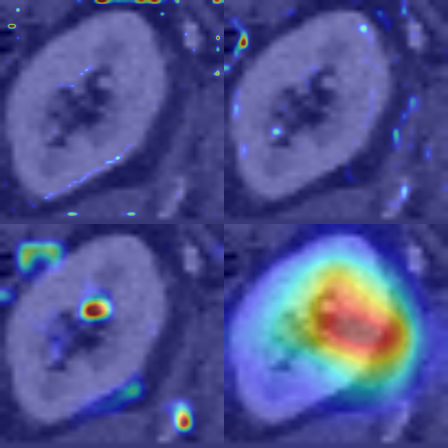

In [22]:
list_ = []
for i in range(1, 5):
    result, predicted_class_name, true_class_name = generate_grad_cam_image(resnet, test_loader, idx,
                                                                            target_layer=f"layer{i}")
    list_.append(result)
concat_images(list_)


 99%|█████████▉| 9898/9998 [02:49<00:01, 54.40it/s]
10026it [02:52, 54.37it/s]                         
10126it [02:54, 54.39it/s]
                          
PartitionExplainer explainer: 2it [03:00, 180.93s/it]              
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


True Class: melanocytic nevi


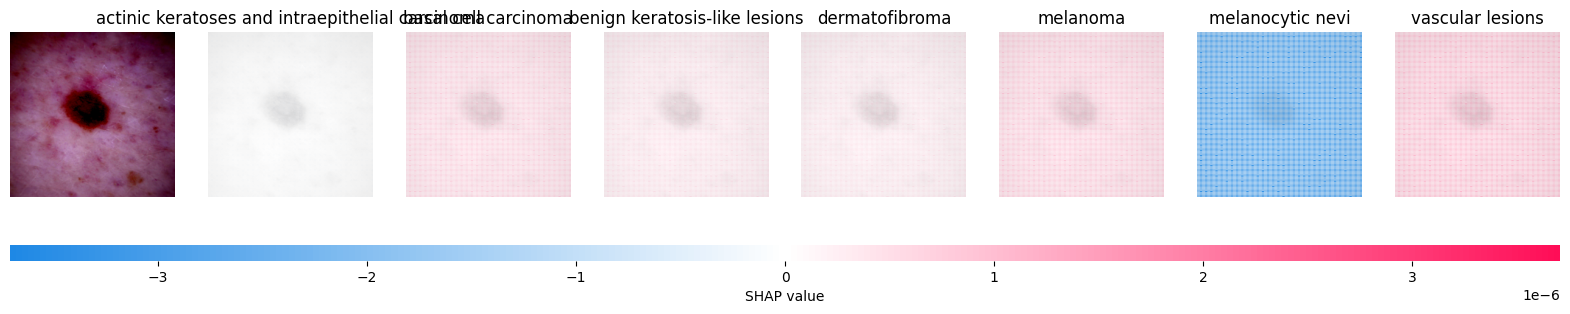

In [249]:
shap_values, class_name = generate_shap_explanation(resnet, test_loader, idx, max_evals=10000, batch_size=128)